In [1]:
 ## 6/7

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score



In [3]:
df=pd.read_csv('heart disease classification dataset.csv')
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [4]:
 ## 7/7

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    str    
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    str    
dtypes: float64(4), int64(9), str(2)
memory usage: 37.8 KB


In [6]:
df['sex']=df['sex'].astype(object)
df['target']=df['target'].astype(object)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    object 
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    object 
dtypes: float64(4), int64(9), object(2)
memory usage: 35.6+ KB


In [8]:
df= df.drop('Unnamed: 0', axis=1)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,female,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no
299,45,male,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no
300,68,male,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no
301,57,male,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3,no


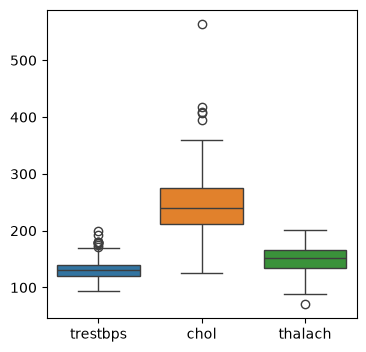

In [11]:
plt.figure(figsize=(4,4))
sns.boxplot(data=df[['trestbps','chol','thalach']])
plt.show()

In [12]:
df['trestbps']=df['trestbps'].fillna(df['trestbps'].median())
df['chol']=df['chol'].fillna(df['chol'].median())
df['thalach']=df['thalach'].fillna(df['thalach'].median())
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
df = pd.get_dummies(df,columns=['sex'],drop_first=True)
df

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,no,True


In [14]:
df['target'].value_counts()

target
yes    165
no     138
Name: count, dtype: int64

In [15]:
df['target']= df['target'].map({'yes': 1, 'no': 0})
df

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,0,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,0,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,0,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,0,True


In [16]:
X=df.drop('target', axis=1)
y=df['target']

In [17]:
X

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,sex_male
0,63,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,True
1,37,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,True
2,41,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,False
3,56,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,True
4,57,0,130.0,354.0,0,1,163.0,1,0.6,2,0,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,False
299,45,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,True
300,68,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,True
301,57,0,130.0,131.0,0,1,115.0,1,1.2,1,1,3,True


In [18]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [20]:
scaler= MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)



In [21]:
X_train_scaled= pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(X_train_scaled)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


          age        cp  trestbps      chol  fbs  restecg   thalach  exang  \
0    0.270833  0.333333  0.265306  0.378753  0.0      0.5  0.649123    0.0   
1    0.604167  0.000000  0.571429  0.321016  0.0      0.0  0.201754    1.0   
2    0.354167  0.666667  0.571429  0.230947  0.0      0.5  0.517544    0.0   
3    0.541667  0.333333  0.418367  0.274827  0.0      0.0  0.640351    0.0   
4    0.645833  0.000000  0.234694  0.228637  1.0      0.5  0.631579    1.0   
..        ...       ...       ...       ...  ...      ...       ...    ...   
237  0.437500  0.666667  0.469388  0.235566  0.0      0.5  0.657895    0.0   
238  0.458333  0.666667  0.000000  0.221709  0.0      0.5  0.578947    1.0   
239  0.833333  1.000000  0.673469  0.237875  1.0      0.0  0.377193    0.0   
240  0.354167  0.000000  0.265306  0.272517  0.0      0.0  0.491228    0.0   
241  0.708333  0.333333  0.469388  0.147806  0.0      0.5  0.798246    0.0   

      oldpeak  slope    ca      thal  sex_male  
0    0.000000 

In [22]:
print(X_test_scaled)


         age        cp  trestbps      chol  fbs  restecg   thalach  exang  \
0   0.621622  0.000000  0.489796  0.530035  0.0      0.0  0.338843    1.0   
1   0.675676  1.000000  0.693878  0.572438  0.0      0.0  0.727273    0.0   
2   0.621622  0.666667  0.489796  0.000000  1.0      1.0  0.842975    0.0   
3   0.594595  0.000000  0.326531  1.000000  0.0      0.0  0.652893    1.0   
4   1.000000  0.666667  0.081633  0.491166  1.0      0.0  0.487603    0.0   
..       ...       ...       ...       ...  ...      ...       ...    ...   
56  0.945946  0.666667  0.387755  0.452297  0.0      0.0  0.619835    0.0   
57  0.432432  0.666667  0.275510  0.247350  0.0      1.0  0.760331    0.0   
58  0.918919  0.000000  0.428571  0.236749  1.0      1.0  0.578512    0.0   
59  0.702703  0.000000  0.438776  0.551237  0.0      0.0  0.586777    1.0   
60  0.432432  0.000000  0.489796  0.413428  0.0      0.0  0.471074    0.0   

     oldpeak  slope    ca      thal  sex_male  
0   0.096774    0.5  0.25  

In [23]:
 ## 8/7

In [24]:
models={
    'logistic regression':LogisticRegression(max_iter=1000),
    'naive bayes':GaussianNB(),
    'decision tree':DecisionTreeClassifier(random_state=42),
    'random forest':RandomForestClassifier(random_state=42)
}

In [25]:
results={}
for name, model in models.items():
    print(f'\n========{name}===')
    if name in ["logistic regression","naive bayes"]:
        model.fit(X_train_scaled,y_train)
        y_pred=model.predict(X_test_scaled)
    else:
        model.fit(X_train,y_train)
        y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    pre=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results[name] = [acc,pre, rec, f1]
    print('Accuracy', acc)
    print('Precision', pre)
    print('Recall', rec)
    print('F1-score', f1)
results_df=pd.DataFrame(results, index=['Accuracy','Precision','Recall','F1-score']).T
results_df    


========logistic regression===
Accuracy 0.8524590163934426
Precision 0.8709677419354839
Recall 0.84375
F1-score 0.8571428571428571

========naive bayes===
Accuracy 0.8688524590163934
Precision 0.875
Recall 0.875
F1-score 0.875

========decision tree===
Accuracy 0.819672131147541
Precision 0.8620689655172413
Recall 0.78125
F1-score 0.819672131147541

========random forest===
Accuracy 0.8360655737704918
Precision 0.84375
Recall 0.84375
F1-score 0.84375


,Accuracy,Precision,Recall,F1-score
logistic regression,0.852459,0.870968,0.84375,0.857143
naive bayes,0.868852,0.875000,0.87500,0.875000
decision tree,0.819672,0.862069,0.78125,0.819672
random forest,0.836066,0.843750,0.84375,0.843750


In [26]:

best_model_name=results_df["Recall"].idxmax()
print('best model based on recall:',best_model_name)
best_model=models[best_model_name]
if best_model_name in ['logistic regression','naive bayes']:
    best_model.fit(X_train_scaled,y_train)
else:
    best_model.fit(X_train,y_train)
with open('model.pkl','wb') as f:
    pickle.dump(best_model,f)
if best_model_name in ['logistic regression','naive bayes']:
    with open('scaler.pkl','wb') as f:
        pickle.dump(scaler,f)      

best model based on recall: naive bayes
